## RLC Network Response

In [1]:
# Course utilities (do not modify this cell)
# Generated by post-canvas-notebooks. Edits above the marker are overwritten.
from pathlib import Path
import sys


def _find_courseutils():
    """Find courseutils no matter where the course repo was cloned."""
    here = Path.cwd().resolve()

    for parent in [here] + list(here.parents):
        for candidate in (parent / "courseutils",
                          parent / "Signals_and_Systems" / "courseutils"):
            if (candidate / "basic_material.py").is_file():
                return candidate.resolve()

    raise FileNotFoundError(
        "Could not find the 'courseutils' folder. Clone "
        "https://github.com/mit-acl/Signals_and_Systems and run this "
        "notebook from inside the cloned repository, then restart the kernel."
    )


COURSEUTILS_DIR = _find_courseutils()

# courseutils is used both as a folder of modules and as a package,
# since control_materials does "import courseutils.basic_material",
# so the folder and its parent both go on the path.
for _location in (COURSEUTILS_DIR.parent, COURSEUTILS_DIR):
    if str(_location) not in sys.path:
        sys.path.insert(0, str(_location))

for _folder in ("data", "figs"):
    Path(_folder).mkdir(exist_ok=True)

# --- end course setup ---

import csv

import basic_material as bm
bm.setup_environment()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sympy.abc import t, x
from sympy.interactive import init_printing
init_printing(pretty_print=True)

from lcapy import Circuit, j, omega, s, exp
from lcapy import R, C, L, symbol

from IPython.display import display, Javascript
display(Javascript('document.title = "RC and RL Networks Response";'))

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/lcapy/__init__.py:76: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<IPython.core.display.Javascript object>

 # Voltage at nodes 2,3 is initially pinned at 5V and then that voltage is removed at time 0. 
 
 * Thus capacitor initially at 5V.

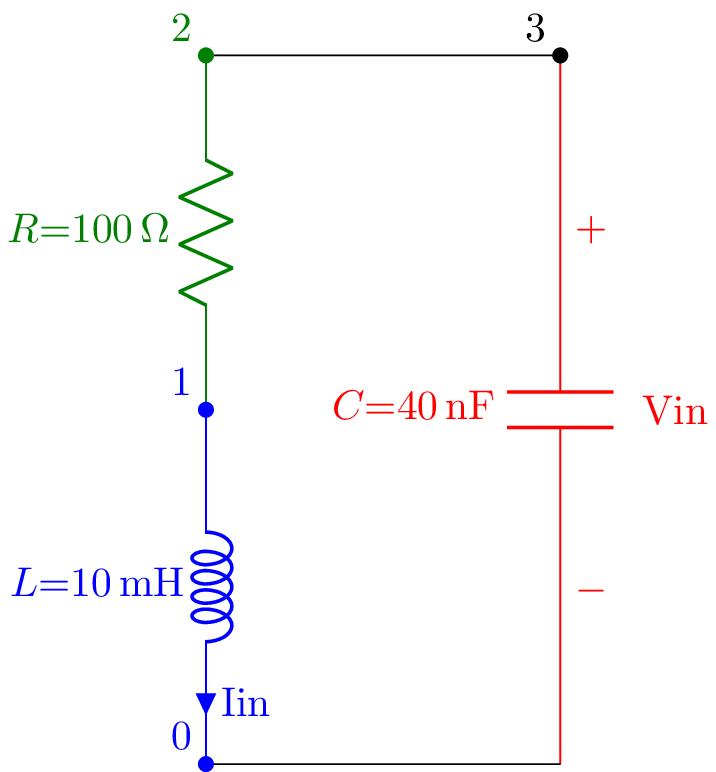

Initial inductor current =   1/20 A


In [3]:
# Set some parameters 
Vin = 5
RR = 100 # resistor
CC = 40e-9 # capacitor value
LL = 10e-3 # inductor value

cct7 = Circuit("""
L 1 0 L {Iin}; down=1.5, i = Iin, color=blue
R 2 1 R ; down=1.5, color=green!50!black
W 2 3; right=1.5
C 3 0_3 C Vin; down=1.5, v = Vin, , color=red
W 0 0_3; right""")

cct7a = cct7.subs({'Vin':Vin, 'R': RR, 'C':CC, 'L':LL, 'Iin':Vin/RR})
cct7a.draw()

# resulting from the initial built up capacitor voltage will be a current through the inductor
print('Initial inductor current =  ',cct7a.L.i(0),'A')

In [4]:
wn = 1/np.sqrt(LL*CC)
zeta = RR/LL/2/wn
wd = wn*np.sqrt(1-zeta**2)
print(f"\tFrequency \t= {wn:.1f} rad/sec")
print(f"\tDamped Freq \t= {wd:.1f} rad/sec")
print(f"\tDamping ratio \t= {(zeta):.2f}")
print(f"\tReal part \t= {(-zeta*wn):.1f}") 

	Frequency 	= 50000.0 rad/sec
	Damped Freq 	= 49749.4 rad/sec
	Damping ratio 	= 0.10
	Real part 	= -5000.0


# Compute time response

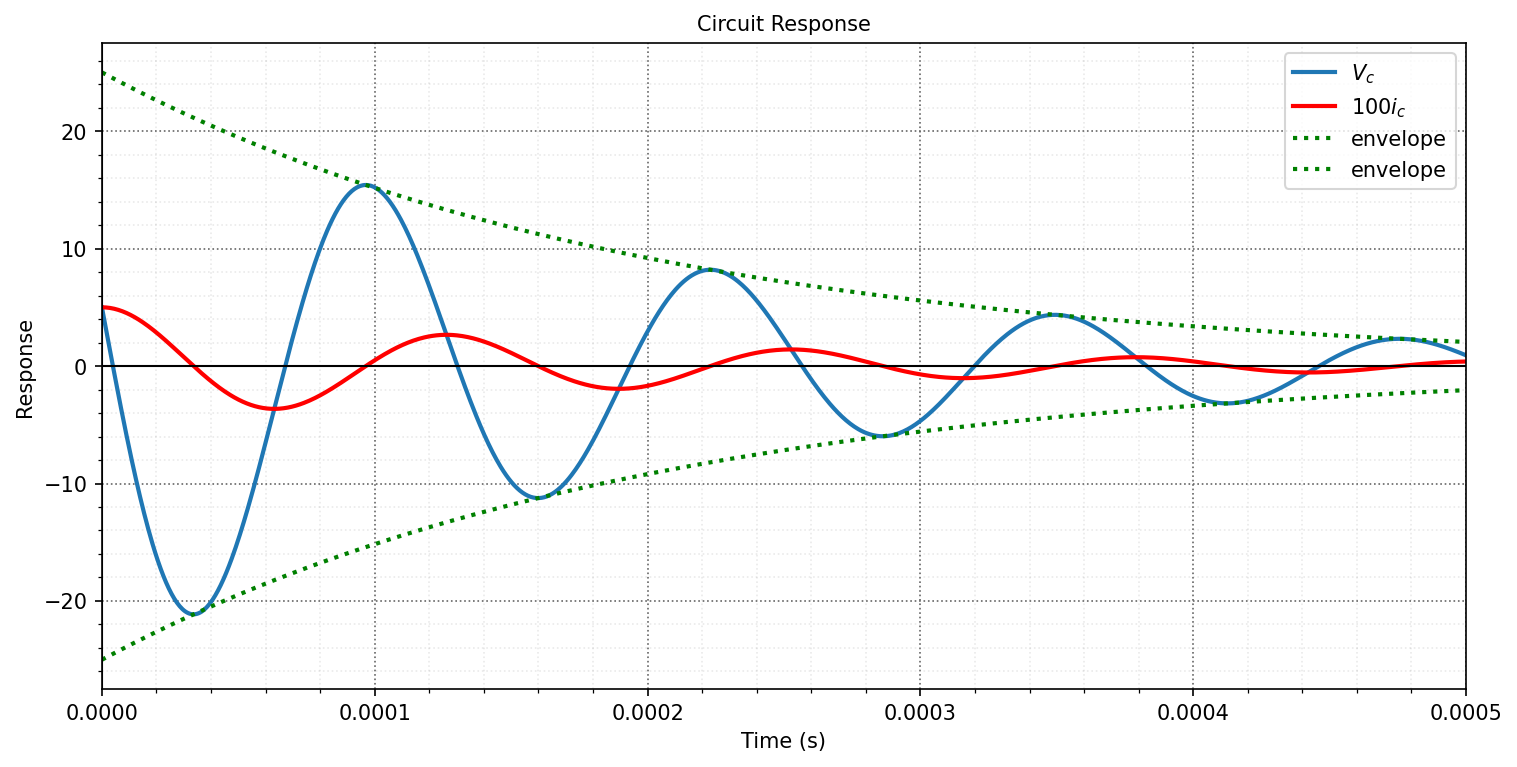

In [5]:
t = np.linspace(0, 5e-4, 1000)
vr = cct7a.C.v.evaluate(t) # capacitor voltage
vi = 100*cct7a.L.i.evaluate(t) # scaled up inductor current

fig = plt.figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(t, vr, linewidth=2, label='$V_c$')
ax.plot(t, vi, linewidth=2, color='red', label='100$i_c$')
ax.plot(t, 25*np.exp(-t*wn*zeta), 'g:', linewidth=2, label='envelope')
ax.plot(t, -25*np.exp(-t*wn*zeta), 'g:', linewidth=2, label='envelope')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
bm.nicegrid(ax)
ax.set_xlim(0,0.0005)
plt.legend()
plt.show()

**Note:** Very large voltage fluctations that occur in the capacitor and the very short time scales involved